● Fetch live stock prices
● Analyze stock performance
● Calculate average price movement
● Visualize stock trends
● Compare multiple companies
● Export stock analytics reports

In [2]:
import requests
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np


# my_request=requests.get("https://www.alphavantage.co/query?function=FX_DAILY&from_symbol=EUR&to_symbol=USD&apikey=demo")


API_KEY = "ECX8ZYJ5VVDPHSZ2"
symbol = "AAPL"

url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={API_KEY}"
my_request=requests.get(url)
print(my_request.status_code)
data=my_request.json()
print(data)

200
{'Global Quote': {'01. symbol': 'AAPL', '02. open': '331.9800', '03. high': '334.9900', '04. low': '329.0006', '05. price': '333.7400', '06. volume': '63407059', '07. latest trading day': '2026-07-17', '08. previous close': '333.2600', '09. change': '0.4800', '10. change percent': '0.1440%'}}


In [3]:
df=pd.DataFrame(data)
df

,Global Quote
01. symbol,AAPL
02. open,331.9800
03. high,334.9900
04. low,329.0006
05. price,333.7400
06. volume,63407059
07. latest trading day,2026-07-17
08. previous close,333.2600
09. change,0.4800
10. change percent,0.1440%


In [4]:
print(df.to_string())

                       Global Quote
01. symbol                     AAPL
02. open                   331.9800
03. high                   334.9900
04. low                    329.0006
05. price                  333.7400
06. volume                 63407059
07. latest trading day   2026-07-17
08. previous close         333.2600
09. change                   0.4800
10. change percent          0.1440%


In [5]:
url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={symbol}&outputsize=compact&apikey={API_KEY}"

data = requests.get(url).json()
print(data)
# df2=pd.DataFrame(data)
# df2

{'Meta Data': {'1. Information': 'Daily Prices (open, high, low, close) and Volumes', '2. Symbol': 'AAPL', '3. Last Refreshed': '2026-07-17', '4. Output Size': 'Compact', '5. Time Zone': 'US/Eastern'}, 'Time Series (Daily)': {'2026-07-17': {'1. open': '331.9800', '2. high': '334.9900', '3. low': '329.0006', '4. close': '333.7400', '5. volume': '63407059'}, '2026-07-16': {'1. open': '328.0050', '2. high': '334.6800', '3. low': '326.7900', '4. close': '333.2600', '5. volume': '62970617'}, '2026-07-15': {'1. open': '317.6150', '2. high': '328.7300', '3. low': '317.3200', '4. close': '327.5000', '5. volume': '60957644'}, '2026-07-14': {'1. open': '313.7600', '2. high': '316.1900', '3. low': '311.9100', '4. close': '314.8600', '5. volume': '36336829'}, '2026-07-13': {'1. open': '317.0150', '2. high': '323.4500', '3. low': '315.7800', '4. close': '317.3100', '5. volume': '43257804'}, '2026-07-10': {'1. open': '314.7200', '2. high': '316.9100', '3. low': '312.1700', '4. close': '315.3200', '5

In [6]:
prices = []

daily = data["Time Series (Daily)"]

for date in daily:
    prices.append(float(daily[date]["4. close"]))

df = pd.DataFrame(prices, columns=["Close"])

average = df["Close"].mean()

print("Average Closing Price:", average)

Average Closing Price: 282.236


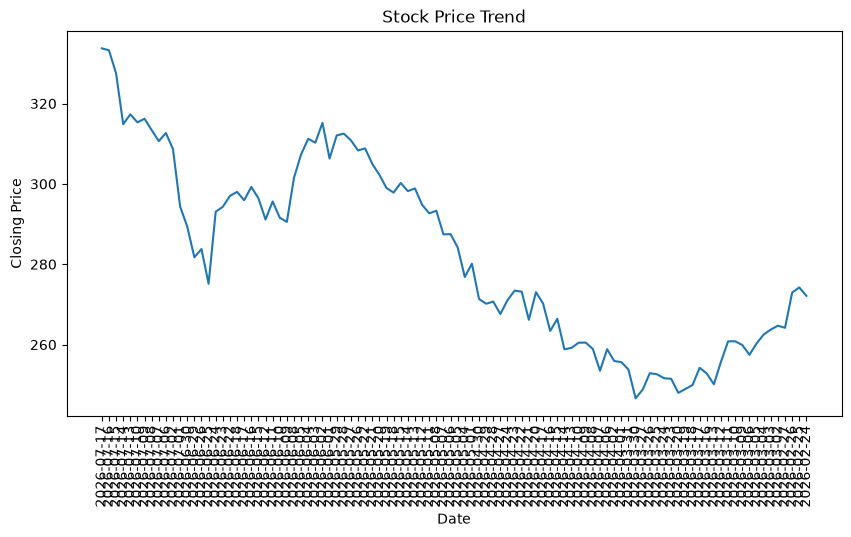

In [7]:
dates = list(daily.keys())
close = [float(daily[d]["4. close"]) for d in dates]

plt.figure(figsize=(10,5))
plt.plot(dates, close)
plt.title("Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=90)
plt.show()

In [8]:
companies = ["AAPL", "MSFT", "GOOGL", "AMZN"]

for company in companies:

    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={company}&apikey={API_KEY}"

    data = requests.get(url).json()

    quote = data["Global Quote"]

    print(company)
    print("Price:", quote["05. price"])
    print("Change %:", quote["10. change percent"])
    print()

AAPL
Price: 333.7400
Change %: 0.1440%

MSFT
Price: 393.8200
Change %: -1.8150%

GOOGL
Price: 346.7700
Change %: -2.1695%

AMZN
Price: 247.2300
Change %: -1.0645%



In [9]:
records = []

for date in daily:

    records.append({
        "Date": date,
        "Open": daily[date]["1. open"],
        "High": daily[date]["2. high"],
        "Low": daily[date]["3. low"],
        "Close": daily[date]["4. close"],
        "Volume": daily[date]["5. volume"]
    })

df = pd.DataFrame(records)


In [10]:
print(df)

          Date      Open      High       Low     Close    Volume
0   2026-07-17  331.9800  334.9900  329.0006  333.7400  63407059
1   2026-07-16  328.0050  334.6800  326.7900  333.2600  62970617
2   2026-07-15  317.6150  328.7300  317.3200  327.5000  60957644
3   2026-07-14  313.7600  316.1900  311.9100  314.8600  36336829
4   2026-07-13  317.0150  323.4500  315.7800  317.3100  43257804
..         ...       ...       ...       ...       ...       ...
95  2026-03-02  262.4100  266.5300  260.2000  264.7200  41827946
96  2026-02-27  272.8100  272.8100  262.8900  264.1800  72366505
97  2026-02-26  274.9450  276.1100  270.7950  272.9500  32345114
98  2026-02-25  271.7800  274.9400  271.0500  274.2300  33714342
99  2026-02-24  267.8600  274.8900  267.7100  272.1400  47014619

[100 rows x 6 columns]


In [ ]:
dates = list(daily.keys())
close = [float(daily[d]["4. close"]) for d in dates]

plt.figure(figsize=(10,5))
plt.plot(dates, close)
plt.title("Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=90)
plt.show()

In [11]:

df.to_csv("stock_report.csv", index=False)

print("Report exported successfully.")

Report exported successfully.
